### Data Preparation 

We use Dataset of Real Waste [Link](https://archive.ics.uci.edu/dataset/908/realwaste)

In [103]:
# setup the realwaste_data.csv for the custom dataset class
# saved path : in data/realwaste_data.csv
from pathlib import Path
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from torch import optim

ROOT = Path("../data/RealWasteData/realwaste-main/RealWaste")
OUT  = Path("../data/realwaste_data.csv")

classes = sorted(d.name for d in ROOT.iterdir() if d.is_dir())
class_to_idx = {c: i for i, c in enumerate(classes)}

rows, bad = [], []
for c in classes:
    for p in sorted((ROOT / c).glob("*.jpg")):
        try:
            with Image.open(p) as im:
                im.verify()                      # catch truncated/corrupt files now
                w, h = im.size
        except Exception as e:
            bad.append((p, e)); continue
        rows.append({
            "filepath": p.relative_to(ROOT).as_posix(),   # "Paper/Paper_1.jpg"
            "class_name": c,
            "label": class_to_idx[c],
            "width": w, "height": h,
        })

df = pd.DataFrame(rows)
df.to_csv(OUT, index=False)
print(f"{len(df)} images, {len(bad)} unreadable -> {OUT}")



4752 images, 0 unreadable -> ../data/realwaste_data.csv


In [104]:
# custom data set
import os
import pandas as pd
from torchvision.io import decode_image

class RealWasteDataset(Dataset):
    """
    custom datset.
        data_file - data/realwaste_data.csv
        image_path -  data/RealWasteData/realwaste-main/RealWaste
    """
    def __init__(self, data_file, image_path, transform=None):
        self.image_path = Path(image_path)
        self.image_lables = pd.read_csv(data_file)
        self.transform = transform

        # label -> class name mapping, taken from the manifest
        pairs = self.image_lables[["label", "class_name"]].drop_duplicates().sort_values("label")
        self.classes = pairs.class_name.tolist()
        self.class_to_idx = dict(zip(pairs.class_name, pairs.label))

    def __len__(self):
        return len(self.image_lables)

    def __getitem__(self, index):
        row = self.image_lables.iloc[index]
        image = Image.open(self.image_path / row.filepath).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, int(row.label)

    @property
    def targets(self):
        """All labels in manifest order, for stratifying the split."""
        return self.image_lables.label.tolist()


In [105]:
# test the class
ds = RealWasteDataset(
    "../data/realwaste_data.csv",
    "../data/RealWasteData/realwaste-main/RealWaste",
)

image, label = ds[3000]
print(len(ds), image.size, image.mode, label)


4752 (524, 524) RGB 5


In [106]:
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from torchvision import transforms


manifest = "../data/realwaste_data.csv"
dataset_root = "../data/RealWasteData/realwaste-main/RealWaste"

base = RealWasteDataset(manifest, dataset_root)
# targets 
y = base.targets


# transfrom to 64*64
train_tf = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# transfrom without augemntation to 64*64
eval_tf = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# train test split 
idx_train, idx_temp = train_test_split(
    range(len(y)), test_size = 0.3, stratify=y, random_state=42
)

y_temp = [y[i] for i in idx_temp]

idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, stratify=y_temp, random_state=42
)


# Dataset - train with augmentation, val/test without 
train_ds = Subset(RealWasteDataset(manifest, dataset_root, transform=train_tf), idx_train)
val_ds = Subset(RealWasteDataset(manifest, dataset_root, transform=eval_tf), idx_val)
test_ds = Subset(RealWasteDataset(manifest, dataset_root, transform=eval_tf), idx_test)
print(f"Traing size : {len(train_ds)}")
print(f"validation size : {len(val_ds)}")
print(f"tast size {len(test_ds)}")

# dataloder 
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

# len(train_loader)
# len(val_loader)
# len(test_loader)


Traing size : 3326
validation size : 713
tast size 713


Feature batch shape: torch.Size([64, 3, 64, 64])
Labels batch shape: torch.Size([64])


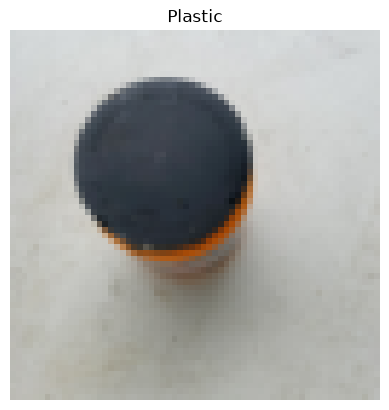

In [107]:
import matplotlib.pyplot as plt
import torch

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

train_features, train_labels = next(iter(train_loader))
print(f"Feature batch shape: {train_features.size()}")   # [64, 3, 64, 64]
print(f"Labels batch shape: {train_labels.size()}")      # [64]

img = train_features[0] * std + mean        # undo Normalize
img = img.clamp(0, 1).permute(1, 2, 0)      # [3,64,64] -> [64,64,3]

plt.imshow(img)
plt.axis("off")
plt.title(base.classes[train_labels[0]])
plt.show()


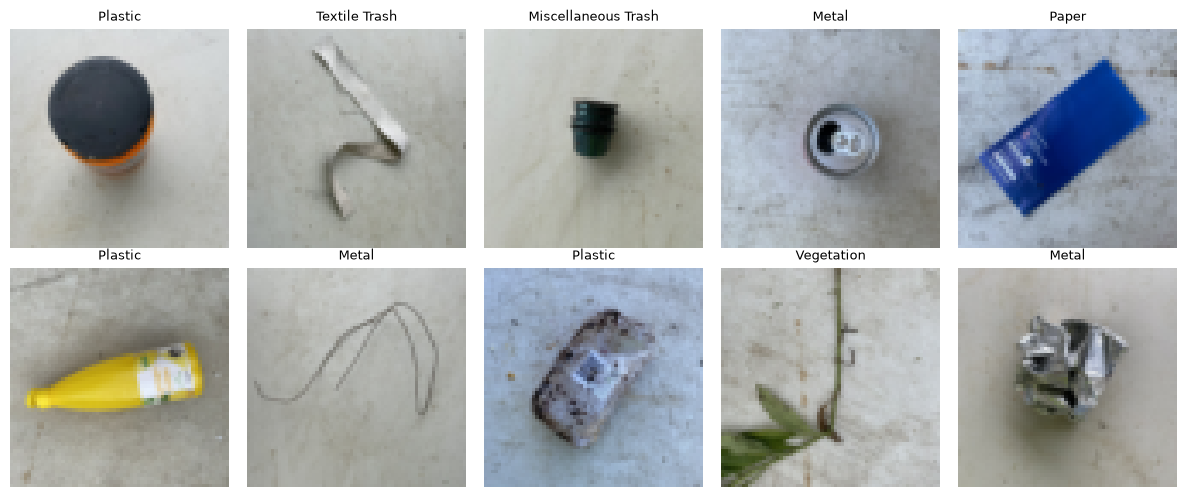

In [108]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, img, lab in zip(axes.flat, train_features, train_labels):
    ax.imshow((img * std + mean).clamp(0, 1).permute(1, 2, 0))
    ax.set_title(base.classes[lab], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## CNN
Building the CNN
1. Standard CNN
2. Light Weight CNN

In [109]:
# standard CNN
import torch.nn as nn

class WasteImageNN(nn.Module):

    def __init__(self):
        super().__init__()
        # features extraction 
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # --> 32*32*32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # --> 64*16*16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True), 
            nn.MaxPool2d(2), # --> 128*8*8

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2) , # 256*4*4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(4096, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 9)
        )

    def forward(self,x):
        return self.classifier(self.features(x))


In [110]:
# create the Nural Network Model

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [111]:
model = WasteImageNN().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

WasteImageNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=4096, out_features=256, bias=True)
    (3): ReLU(inplace=True)
    

## Train for 20 epochs

In [112]:
def train(model, train_loader, val_loader, num_ephohs, lr):
    """
    Train model and track loss

    Args:

        model : Pytorch model
        train_loader : Training Data loader
        num_epohs : # of Epochs
        lr : learning rate

    returns:

        training losses: list of traing losses per epoch
    """
    # check the gpu
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using the device : {device}\n")

    # move the model to device
    model = model.to(device)

    # loss and optimizer
    cirterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_loss = []
    validation_loss = []

    print(f"Training for {num_ephohs} epoches...\n")

    for epoch in range(num_ephohs):
        # ============================= Training =============================
        model.train()
        epoch_loss = 0

        for batch_x, batch_y in train_loader:
            # move batch to the device 
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            # zero gradients 
            optimizer.zero_grad()

            # forward pass 
            outputs = model(batch_x)
            loss = cirterion(outputs, batch_y)

            # backpropagation
            loss.backward()

            # update weights 
            optimizer.step()

            epoch_loss += loss.item()

        # avarage training loss 
        avg_loss = epoch_loss/len(train_loader)
        train_loss.append(avg_loss)

        # ============================= Validation =============================
        model.eval()
        valid_loss = 0

        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                loss = cirterion(outputs, batch_y)
                valid_loss += loss.item()

        avg_valid_loss = valid_loss/len(val_loader)
        validation_loss.append(avg_valid_loss)


        print(f"Epoch [{epoch+1}/{num_ephohs}] | Train Loss: {avg_loss:.4f} |  Validation Loss : {avg_valid_loss:.4f}")

    print("\nTrain is Completed !")
    return train_loss, validation_loss

In [113]:
len(train_loader)

52

In [114]:
## Helper functions
def plot_training_loss(train_losses, validation_losses):
    """Plot training loss."""

    plt.figure(figsize=(10, 5))

    epochs = range(1, len(train_losses)+1)
    plt.plot(epochs,train_losses, marker='o', label="Train_loss")
    plt.plot(epochs,validation_losses, marker='s', label="Validation loss")

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.grid(True, alpha=0.3)
    plt.show()

# evaluvate test 
def evaluate_test(model, test_loader):
    """Evaluate model on test set."""
    # Check for GPU
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            # Move data to device
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            outputs = model(batch_x)
            _, predicted = torch.max(outputs, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()

    test_accuracy = 100 * correct / total
    print(f"\n{'='*50}")
    print(f"TEST ACCURACY: {test_accuracy:.2f}%")
    print(f"{'='*50}")

    return test_accuracy

Using the device : cuda

Training for 20 epoches...

Epoch [1/20] | Train Loss: 2.0573 |  Validation Loss : 1.8303
Epoch [2/20] | Train Loss: 1.6949 |  Validation Loss : 1.4987
Epoch [3/20] | Train Loss: 1.5211 |  Validation Loss : 1.3779
Epoch [4/20] | Train Loss: 1.3679 |  Validation Loss : 1.2877
Epoch [5/20] | Train Loss: 1.2863 |  Validation Loss : 1.2227
Epoch [6/20] | Train Loss: 1.2098 |  Validation Loss : 1.0933
Epoch [7/20] | Train Loss: 1.1122 |  Validation Loss : 1.1322
Epoch [8/20] | Train Loss: 1.0702 |  Validation Loss : 0.9861
Epoch [9/20] | Train Loss: 1.0111 |  Validation Loss : 0.9896
Epoch [10/20] | Train Loss: 0.9482 |  Validation Loss : 0.9652
Epoch [11/20] | Train Loss: 0.9307 |  Validation Loss : 0.9175
Epoch [12/20] | Train Loss: 0.9001 |  Validation Loss : 0.8742
Epoch [13/20] | Train Loss: 0.8531 |  Validation Loss : 1.0135
Epoch [14/20] | Train Loss: 0.8560 |  Validation Loss : 0.8321
Epoch [15/20] | Train Loss: 0.7782 |  Validation Loss : 0.8331
Epoch [16/2

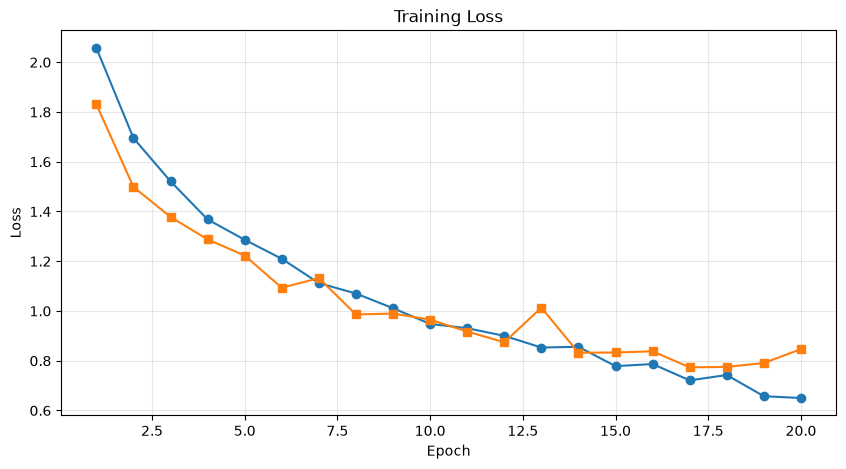


TEST ACCURACY: 68.02%


In [116]:
# Train model 
model = WasteImageNN()
train_loss, validation_loss = train(model=model, train_loader=train_loader, val_loader=val_loader, num_ephohs=20, lr=1e-3)
plot_training_loss(train_losses=train_loss, validation_losses=validation_loss)
test_acc = evaluate_test(model=model, test_loader=test_loader)

In [120]:
# save model 
torch.save(model.state_dict(), Path("../models/model_A.pth"))